In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Amazon.csv to Amazon.csv
Saving Apple.csv to Apple.csv
Saving Facebook.csv to Facebook.csv
Saving Google.csv to Google.csv
Saving Netflix.csv to Netflix.csv


In [ ]:
import os

os.listdir()

['.config',
 'Facebook.csv',
 'Netflix.csv',
 'Google.csv',
 'Amazon.csv',
 'Apple.csv',
 'sample_data']

In [ ]:
import pandas as pd

google = pd.read_csv("Google.csv")
apple = pd.read_csv("Apple.csv")
amazon = pd.read_csv("Amazon.csv")
netflix = pd.read_csv("Netflix.csv")
facebook = pd.read_csv("Facebook.csv")

print("Google:", google.shape)
print("Apple:", apple.shape)
print("Amazon:", amazon.shape)
print("Netflix:", netflix.shape)
print("Facebook:", facebook.shape)

Google: (4041, 7)
Apple: (10016, 7)
Amazon: (5852, 7)
Netflix: (4581, 7)
Facebook: (2076, 7)


In [ ]:
google["Empresa"] = "Google"
apple["Empresa"] = "Apple"
amazon["Empresa"] = "Amazon"
netflix["Empresa"] = "Netflix"
facebook["Empresa"] = "Facebook"

In [ ]:
df = pd.concat(
    [google, apple, amazon, netflix, facebook],
    ignore_index=True
)

print(df.shape)

(26566, 8)


In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Empresa
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000.0,Google
1,2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300.0,Google
2,2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100.0,Google
3,2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300.0,Google
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600.0,Google


In [ ]:
df["Empresa"].value_counts()

,count
Empresa,
Apple,10016
Amazon,5852
Netflix,4581
Google,4041
Facebook,2076


In [ ]:
print(df.shape)


(26566, 8)


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Empresa", "Date"]
)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Empresa
14057,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000.0,Amazon
14058,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000.0,Amazon
14059,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800.0,Amazon
14060,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200.0,Amazon
14061,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200.0,Amazon


In [ ]:
df["Target"] = (
    df.groupby("Empresa")["Close"]
      .shift(-1)
      > df["Close"]
).astype(int)

In [ ]:
df["Target"].value_counts(normalize=True) * 100

,proportion
Target,
1,50.639916
0,49.360084


In [ ]:
df["MA7"] = (
    df.groupby("Empresa")["Close"]
      .transform(lambda x: x.rolling(7).mean())
)

df["MA30"] = (
    df.groupby("Empresa")["Close"]
      .transform(lambda x: x.rolling(30).mean())
)

In [ ]:
df = df.dropna()

variable predictoria

In [ ]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "MA7",
        "MA30"
    ]
]

y = df["Target"]

In [ ]:
print(df.shape)

(26391, 11)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(
    "Accuracy Logistic Regression:",
    accuracy_score(y_test, pred_lr)
)

Accuracy Logistic Regression: 0.4997158552756204


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(
    "Accuracy Random Forest:",
    accuracy_score(y_test, pred_rf)
)

Accuracy Random Forest: 0.5050198901307066


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print(
    "Accuracy Decision Tree:",
    accuracy_score(y_test, pred_dt)
)

Accuracy Decision Tree: 0.4999052850918735


In [ ]:
df["MA7"] = (
    df.groupby("Empresa")["Close"]
      .transform(lambda x: x.rolling(7).mean())
)

In [ ]:
df["MA30"] = (
    df.groupby("Empresa")["Close"]
      .transform(lambda x: x.rolling(30).mean())
)

In [ ]:
df[["Empresa","Close","MA7","MA30"]].head(15)

,Empresa,Close,MA7,MA30
14086,Amazon,1.510417,NaN,NaN
14087,Amazon,1.489583,NaN,NaN
14088,Amazon,1.541667,NaN,NaN
14089,Amazon,1.515625,NaN,NaN
14090,Amazon,1.588542,NaN,NaN
14091,Amazon,1.911458,NaN,NaN
14092,Amazon,2.000000,1.651042,NaN
14093,Amazon,2.302083,1.764137,NaN
14094,Amazon,2.322917,1.883185,NaN
14095,Amazon,2.562500,2.029018,NaN


In [ ]:
df = df.dropna()

In [ ]:
print(df.shape)

(26246, 11)


In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Empresa', 'Target', 'MA7', 'MA30'],
      dtype='object')

In [ ]:
df["Target_Price"] = (
    df.groupby("Empresa")["Close"]
      .shift(-1)
)

In [ ]:
df = df.dropna()

In [ ]:
df[["Empresa","Close","Target_Price"]].head()

,Empresa,Close,Target_Price
14115,Amazon,2.177083,2.291667
14116,Amazon,2.291667,2.328125
14117,Amazon,2.328125,2.197917
14118,Amazon,2.197917,2.197917
14119,Amazon,2.197917,2.156250


In [ ]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "MA7",
        "MA30"
    ]
]

y = df["Target_Price"]

In [ ]:
df["Target_Price"] = (
    df.groupby("Empresa")["Close"]
      .shift(-1)
)

df = df.dropna()

In [ ]:
df[["Empresa","Close","Target_Price"]].head()

,Empresa,Close,Target_Price
14115,Amazon,2.177083,2.291667
14116,Amazon,2.291667,2.328125
14117,Amazon,2.328125,2.197917
14118,Amazon,2.197917,2.197917
14119,Amazon,2.197917,2.156250


In [ ]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "MA7",
        "MA30"
    ]
]

y = df["Target_Price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
predicciones = modelo_lr.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predicciones
)

rmse = mean_squared_error(
    y_test,
    predicciones
) ** 0.5

r2 = r2_score(
    y_test,
    predicciones
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.799363404400912
RMSE: 8.858031267130588
R2: 0.9994654675320379


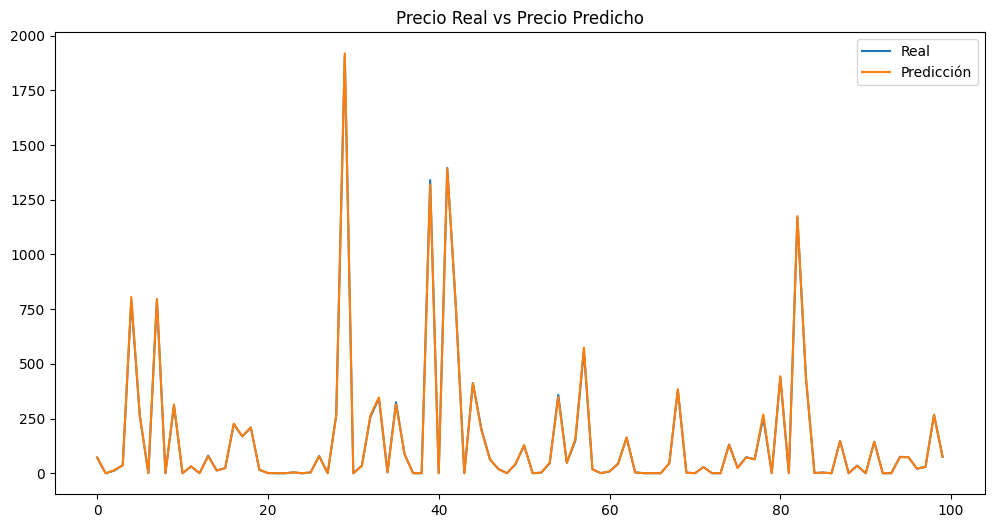

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Real"
)

plt.plot(
    predicciones[:100],
    label="Predicción"
)

plt.legend()

plt.title("Precio Real vs Precio Predicho")

plt.show()

In [ ]:
import pickle

with open("modelo_regresion.pkl", "wb") as f:
    pickle.dump(modelo_lr, f)

In [ ]:
from google.colab import files

files.download("modelo_regresion.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>